In [191]:
from datasets import load_dataset
import os

In [192]:
ds = load_dataset("clip-benchmark/wds_vtab-caltech101", split="test")

In [193]:
print(ds[0].keys())

dict_keys(['__key__', '__url__', 'cls', 'webp'])


In [194]:
img_key = "webp" if "webp" in ds[0] else "jpg"

In [195]:
out_dir = "my_photos"
os.makedirs(out_dir, exist_ok=True)

In [ ]:
import random
random.seed(0)
labels_all = ds["cls"]
unique_labels = sorted(set(labels_all))
chosen_classes = random.sample(unique_labels, 12)

count = 0
per_class_budget = 15
seen_per_class = {c: 0 for c in chosen_classes}

for i, ex in enumerate(ds):
    c = ex["cls"]
    if c in chosen_classes and seen_per_class[c] < per_class_budget:
        img = ex[img_key]
        # filename now encodes the true class label first (e.g. class017_003.jpg)
        # so it can be recovered later for ARI/AMI, and sorts consistently
        fname = f"class{c:03d}_{seen_per_class[c]:03d}.jpg"
        img.convert("RGB").save(os.path.join(out_dir, fname))
        seen_per_class[c] += 1
        count += 1
    if count >= 180:
        break

print(f"Saved {count} images to {out_dir}/")


Saved 153 images to my_photos/


In [197]:
from PIL import Image
import numpy as np

In [198]:
img = Image.open("my_photos/100_8.jpg").convert("RGB")

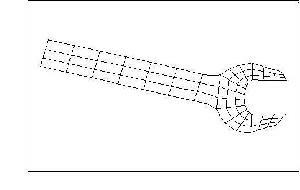

In [199]:
img

In [200]:
img.size

(300, 190)

In [201]:
img = img.resize((64, 64))

In [202]:
img_array = np.array(img)

In [203]:
img_vector = img_array.reshape(-1)

In [204]:
img_vector.shape

(12288,)

In [205]:
folder = "my_photos"
filenames = sorted(f for f in os.listdir(folder) if f.lower().endswith(".jpg"))

raw_vectors = []
for fname in filenames:
    img = Image.open(os.path.join(folder, fname)).convert("RGB")
    img = img.resize((64, 64))
    arr = np.array(img) / 255.0
    raw_vectors.append(arr.flatten())

raw_vectors = np.array(raw_vectors)
print(raw_vectors.shape)


(306, 12288)


In [206]:
# true labels, extracted from filenames
# filenames look like "class017_003.jpg" -> label 17
true_labels = [int(f.split("_")[0].replace("class", "")) for f in filenames]

In [207]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [208]:
X = raw_vectors.astype(np.float32) 

In [209]:
inertias = []
sil_scores = []
k_range = range(5, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels_k))

/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:2

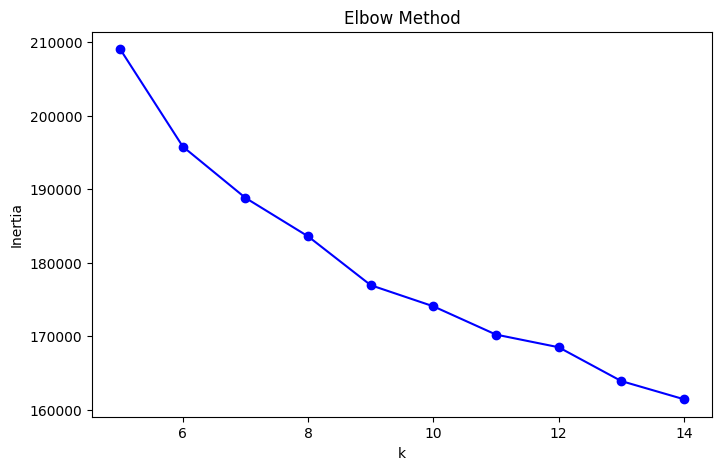

In [210]:
# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'b-o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

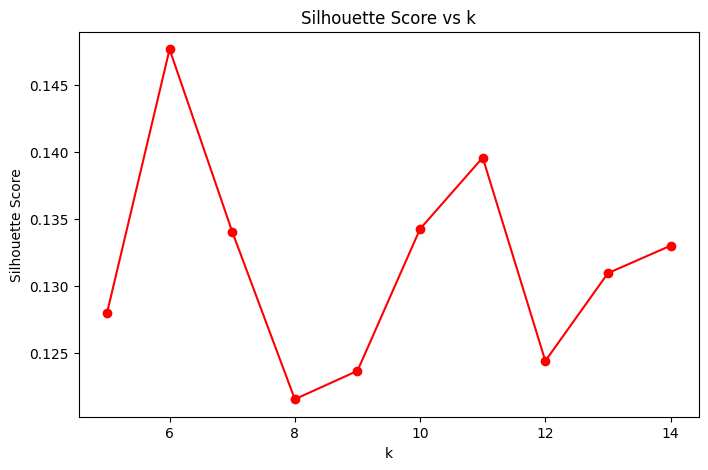

In [211]:
# Silhouette plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, 'r-o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

k=7 was chosen because the elbow curve flattens around k=7-8, and the silhouette score peaks near k=6-7. The two methods agree at k=7.

In [212]:
km_raw_final = KMeans(n_clusters=7, random_state=42, n_init=10)
raw_labels = km_raw_final.fit_predict(X)


/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [213]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

ari_raw = adjusted_rand_score(true_labels, raw_labels)
ami_raw = adjusted_mutual_info_score(true_labels, raw_labels)

print("Raw pixels  -> ARI:", round(ari_raw, 3), " AMI:", round(ami_raw, 3))


Raw pixels  -> ARI: 0.161  AMI: 0.312


k=6 was chosen mainly because of the silhouette score as it has one clear, sharp peak at k=6, noticeably higher than any other value. The elbow plot doesn't have one obvious bend, but the curve does start to flatten out around k=7-8, which is close enough to k=6 that it doesn't really disagree with the silhouette result.

In [214]:
km_raw_final = KMeans(n_clusters=6, random_state=42, n_init=10)
raw_labels = km_raw_final.fit_predict(X)

/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [215]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

ARI(Adjusted Rand Index) measures how similar your clustering is to the true labels.
AMI(Adjusted Mutual Information) measures how much information your clustering shares with the true labels.

In [216]:
ari_raw = adjusted_rand_score(true_labels, raw_labels)
ami_raw = adjusted_mutual_info_score(true_labels, raw_labels)

print("Raw pixels  -> ARI:", round(ari_raw, 3), " AMI:", round(ami_raw, 3))

Raw pixels  -> ARI: 0.122  AMI: 0.262
